# dcngen — first working pipeline: PoC overview

**The first working pipeline.**

This notebook is a guided tour of what the pipeline builds and the data it produced: the Hanoi
topology from DiTEC-WDN, its transformation into a closed-loop district *cooling* network, and the
two proof-of-concept scenarios — one clean-normal day and one with an abrupt leak — that
`scripts/run_poc.py` generated, gated, and wrote to `data/poc/`.

| Component | What it does | Where |
|---|---|---|
| Scaffold | conda env, config, WNTR smoke test | `configs/default.yaml`, `dcngen.config` |
| DCN-ifier | supply/return mirror + Plant + ETS crossovers | `topology/dcnifier.py` |
| Thermal solver | Lagrangian plug transport, exact delay | `thermal/thermal_solver.py` |
| ε-NTU ETS | heat-exchanger physics, fouling-capable, iterated solve | `thermal/ets.py`, `orchestrate/scenario.py` |
| Load generator | archetype daily/weekly profiles + AR(1) noise | `loads/` |
| Fault injector | abrupt junction leak + ground-truth labels | `faults/` |
| Records + graphs | Parquet records + typed heterogeneous graph loader | `records/` |
| Gate + PoC | 8-rule validation gate + `run_poc` end-to-end | `orchestrate/validate.py`, `orchestrate/poc.py` |

**Pipeline in one line:** DiTEC parquet topology → supply/return mirror → archetype cooling loads →
per-timestep hydraulic (WNTR) ⇄ thermal (plugs + ε-NTU) iteration → fault injection → validation
gate → sharded Parquet records → PyTorch-Geometric `HeteroData`.

> Regenerate the data with `python scripts/run_poc.py` (≈ 20 min); this notebook only *reads*
> `data/poc/` and the DiTEC dump — it never solves.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

from dcngen.config import load_config
from dcngen.topology.dcnifier import build_dcn
from dcngen.topology.ditec_loader import load_ditec_network

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
POC = ROOT / "data" / "poc"
assert POC.exists(), "run `python scripts/run_poc.py` first — this notebook only reads its output"

cfg = load_config()

# Validated reference palette (dataviz skill; light mode).
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e8e7e3", "#fcfcfb"
SEQ_BLUES = LinearSegmentedColormap.from_list(
    "seq_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)
ARCHETYPE_COLOR = {
    "office": BLUE, "hotel": ORANGE, "retail": AQUA, "residential": YELLOW,
}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "figure.titlesize": 14,
    "legend.frameon": False, "figure.dpi": 110,
})


def table(scenario, name):
    return pd.read_parquet(POC / scenario / f"{name}.parquet")


cards = {s: json.loads((POC / s / "card.json").read_text()) for s in ("normal", "leak")}
HOURS = np.arange(cards["normal"]["n_steps"]) * cards["normal"]["dt"] / 3600.0
fault = cards["leak"]["fault"]
print(f"network: {cards['normal']['network']}  "
      f"({cards['normal']['n_steps']} steps of {cards['normal']['dt']:.0f} s)")
print(f"normal seed: {cards['normal']['seed']}")
print(f"leak   seed: {cards['leak']['seed']}")
print(f"leak fault:  junction {fault['location']} ({fault['side']} side), "
      f"severity {fault['severity']:.3f}, onset {fault['onset'] / 3600:.1f} h")

network: hanoi_8GB_1Y  (144 steps of 600 s)
normal seed: 4047939128787533792
leak   seed: 7919168045412322066
leak fault:  junction 18 (return side), severity 0.047, onset 9.7 h


## 1 · The substrate and the supply/return mirror

DiTEC-WDN provides Hanoi as a *water-distribution* graph: 31 junctions, 34 pipes, one reservoir,
demand-driven. The DCN-ifier turns it into a closed-loop **district cooling** network:

- every junction `j` becomes a **supply twin** `j_s` and a **return twin** `j_r`;
- every pipe is mirrored onto both layers, the return copy **reversed**, so in normal operation
  the same water shows the same signed flow on both sides;
- each consumer gets an **ETS crossover** `j_s → j_r` — the graph form of its heat-exchanger
  substation, carrying the primary flow the ε-NTU model demands;
- the DiTEC reservoir site hosts the **Plant** (reservoir + pump + return stub): pressure
  reference, circulation head, make-up water, and the thermal boundary condition
  *"whatever arrives leaves at the 6 °C supply setpoint"*.

Design flows follow **flow equivalence**: each consumer's design primary flow *is* its
DiTEC base demand, so the mirrored network operates in the hydraulic regime its pipes were
validated in.

In [2]:
net = load_ditec_network(Path(cfg.paths.ditec_data) / cfg.poc.network, cfg.poc.static_scenario_id)
dcn = build_dcn(net, cfg)

print(f"{net.name}: {len(net.junctions)} junctions, {len(net.pipes)} pipes, "
      f"{len(dcn.consumers)} consumers (all junctions host an ETS here)")
print(f"WNTR mirror: {len(dcn.wn.junction_name_list)} nodes, {len(dcn.wn.pipe_name_list)} pipes, "
      f"{len(dcn.consumers)} FCV crossovers + plant triple")
print(f"plant design point: {dcn.pump_design[0]:.2f} m3/s @ {dcn.pump_design[1]:.1f} m head")
archetypes = table("normal", "node_static").set_index("junction")["archetype"]

hanoi_8GB_1Y: 31 junctions, 34 pipes, 31 consumers (all junctions host an ETS here)
WNTR mirror: 64 nodes, 69 pipes, 31 FCV crossovers + plant triple
plant design point: 8.63 m3/s @ 29.7 m head


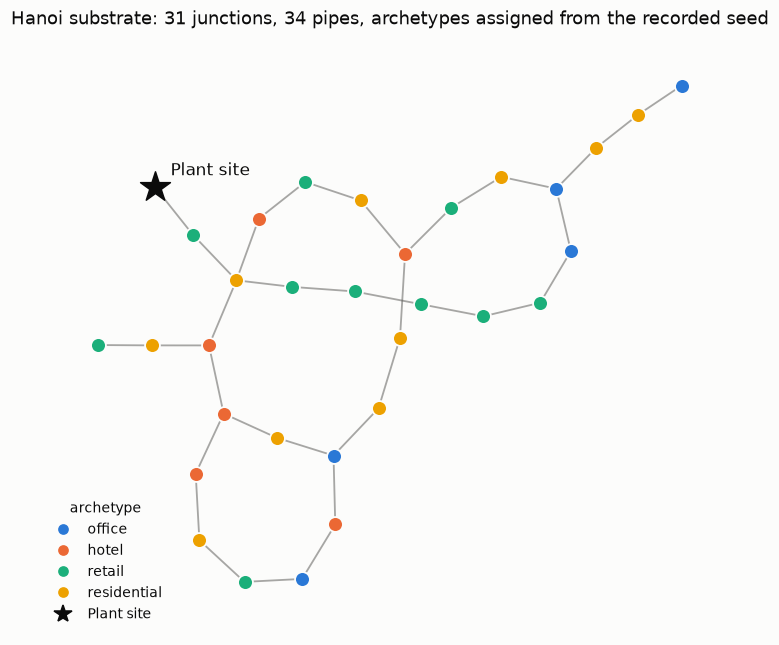

In [ ]:
site = cards["normal"]["plant"]["site"]
base = nx.Graph()
for a, b, pipe in cards["normal"]["adj_list"]:
    base.add_edge(a, b)
pos = nx.kamada_kawai_layout(base)

# the original WDN graph, consumers coloured by assigned archetype
fig, ax = plt.subplots(figsize=(6.75, 6))
nx.draw_networkx_edges(base, pos, ax=ax, edge_color=INK2, width=1.2, alpha=0.5)
for arch, colour in ARCHETYPE_COLOR.items():
    nodes = [j for j in base if j != site and archetypes.get(j) == arch]
    nx.draw_networkx_nodes(base, pos, nodelist=nodes, ax=ax, node_size=95,
                           node_color=colour, edgecolors=SURFACE, linewidths=1.2)
ax.scatter(*pos[site], marker="*", s=420, color=INK, zorder=5)
ax.annotate("Plant site", pos[site], textcoords="offset points", xytext=(10, 8), color=INK)
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", color=c, label=a) for a, c in ARCHETYPE_COLOR.items()
] + [Line2D([], [], marker="*", ls="", color=INK, markersize=12, label="Plant site")],
    loc="lower left", fontsize=9, title="archetype", title_fontsize=9)
ax.set_title("Hanoi substrate: 31 junctions, 34 pipes, archetypes assigned from the recorded seed")
ax.set_axis_off()
plt.tight_layout()
plt.show()

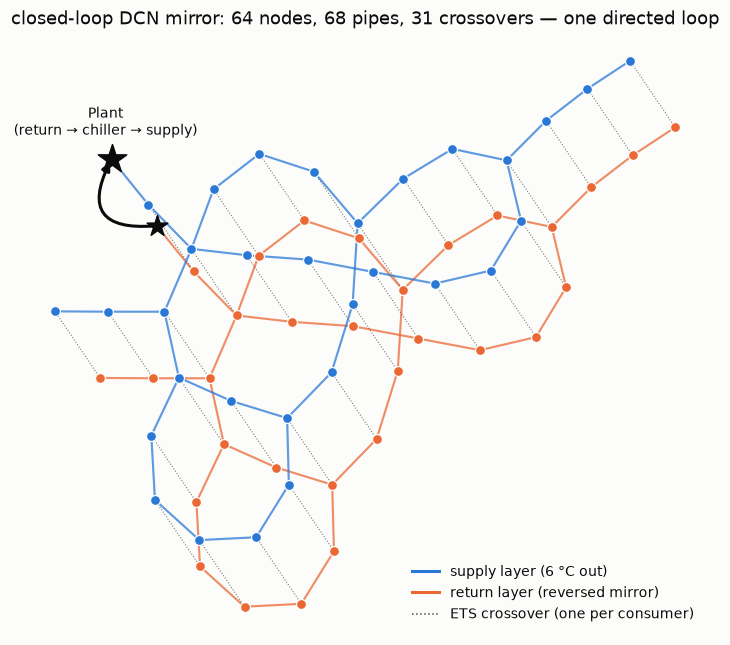

In [ ]:
# the mirror — supply layer (blue), reversed return layer (orange),
# one ETS crossover per consumer, the Plant closing the loop
fig, ax = plt.subplots(figsize=(6.75, 6))
shift = np.array([0.14, -0.18])
pos_r = {j: pos[j] + shift for j in base}
for a, b in base.edges:
    ax.plot(*zip(pos[a], pos[b]), color=BLUE, lw=1.4, alpha=0.75, zorder=2)
    ax.plot(*zip(pos_r[a], pos_r[b]), color=ORANGE, lw=1.4, alpha=0.75, zorder=1)
for j in base:
    if j == site:
        continue
    ax.plot(*zip(pos[j], pos_r[j]), color=INK2, lw=0.7, ls=":", alpha=0.8, zorder=1)
xy_s = np.array([pos[j] for j in base if j != site])
xy_r = np.array([pos_r[j] for j in base if j != site])
ax.scatter(*xy_s.T, s=42, color=BLUE, edgecolors=SURFACE, linewidths=0.8, zorder=3)
ax.scatter(*xy_r.T, s=42, color=ORANGE, edgecolors=SURFACE, linewidths=0.8, zorder=3)
# the plant closes the loop: both plant headers starred, the arrow bowed
# outward into the empty corner so it does not cross the network
ax.annotate("", xy=pos[site], xytext=pos_r[site],
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=2.0,
                            connectionstyle="arc3,rad=-0.9"), zorder=6)
ax.scatter(*pos[site], marker="*", s=380, color=INK, zorder=6)
ax.scatter(*pos_r[site], marker="*", s=200, color=INK, zorder=6)
ax.annotate("Plant\n(return → chiller → supply)", pos[site],
            textcoords="offset points", xytext=(-4, 16), ha="center", color=INK, fontsize=9)
ax.legend(handles=[
    Line2D([], [], color=BLUE, lw=2, label="supply layer (6 °C out)"),
    Line2D([], [], color=ORANGE, lw=2, label="return layer (reversed mirror)"),
    Line2D([], [], color=INK2, lw=1, ls=":", label="ETS crossover (one per consumer)"),
], loc="lower right", fontsize=9)
ax.set_title("closed-loop DCN mirror: 64 nodes, 68 pipes, 31 crossovers — one directed loop")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2 · The PoC pair and the validation gate

`run_poc` derives three recorded sub-seeds from the master seed (42): archetype assignment, the
normal day, the leak day. Each scenario runs the full per-timestep loop — loads → FCV settings →
WNTR PDD solve → plug transport → ε-NTU energy balance → convergence check — then faces the
**8-rule validation gate** before being written. Both scenarios must pass for the run to
print `definition of done: PASS`.

In [4]:
rows = {}
for scenario, card in cards.items():
    for r in card["validation"]["rules"]:
        rows.setdefault(r["rule"], {})[scenario] = "PASS" if r["passed"] else "FAIL"
        rows[r["rule"]]["detail (leak run)"] = next(
            x["detail"] for x in cards["leak"]["validation"]["rules"] if x["rule"] == r["rule"]
        )
gate = pd.DataFrame(rows).T[["normal", "leak", "detail (leak run)"]]
gate.index.name = "gate rule"
gate

,normal,leak,detail (leak run)
gate rule,,,
mass_balance,PASS,PASS,max |make-up - leak| = 1.776e-15 m3/s (tol 8.6...
energy_closure,PASS,PASS,"post-turnover mean residual 0.00% (tol 3%, win..."
temperature_envelope,PASS,PASS,"temperatures span [6.00, 14.00] degC (envelope..."
velocity_envelope,PASS,PASS,max v/circulation-cap = 0.39; loop redistribu...
pressure_rails,PASS,PASS,"floor margin 89.4 m, ceiling margin 15.5 m, pl..."
ets_reverse_flow,PASS,PASS,min crossover flow 3.038e-02 m3/s
unmet_load,PASS,PASS,unmet outside fault window: 0.0%; under fault ...
convergence_budget,PASS,PASS,0.0% unconverged steps (budget 1%)


## 3 · Cooling loads — what drives everything

Loads are per-consumer archetype profiles (stylised daily knot curves) with mean-one
multiplicative AR(1) noise, sized by flow equivalence. The hinge equation
`ṁ = Q / (c_p·ΔT)` turns each load into the primary flow its ETS valve requests.

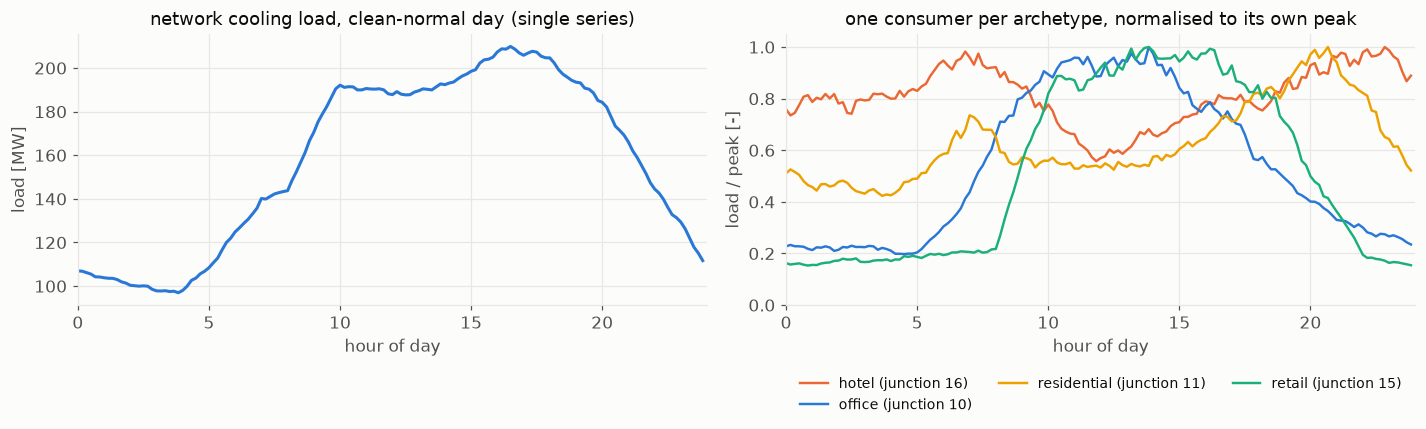

In [5]:
nodes_n = table("normal", "node_dynamics")
load_wide = nodes_n.pivot(index="time_id", columns="junction", values="cooling_load")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax1.plot(HOURS, load_wide.sum(axis=1) / 1e6, color=BLUE, lw=2)
ax1.set_title("network cooling load, clean-normal day (single series)")
ax1.set_xlabel("hour of day")
ax1.set_ylabel("load [MW]")
ax1.set_xlim(0, 24)

picked = {}
for j, arch in archetypes.items():
    picked.setdefault(arch, j)  # first consumer of each archetype
for arch, j in sorted(picked.items()):
    series = load_wide[j] / load_wide[j].max()
    ax2.plot(HOURS, series, color=ARCHETYPE_COLOR[arch], lw=1.6,
             label=f"{arch} (junction {j})")
ax2.set_title("one consumer per archetype, normalised to its own peak")
ax2.set_xlabel("hour of day")
ax2.set_ylabel("load / peak [-]")
ax2.set_xlim(0, 24)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9, ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.22))
plt.tight_layout()
plt.show()

## 4 · Thermal response — ε-NTU at work

At every consumer the network's 6 °C supply arrives (warmed slightly by pipe heat gain — ground is
at 20 °C), crosses the ETS heat exchanger, and returns near the 13 °C design return. ΔT is an
*output* of the ε-NTU physics, not an assumption — under fouling or overload it collapses, which
is the dominant DCN fault signature this dataset exists to teach.

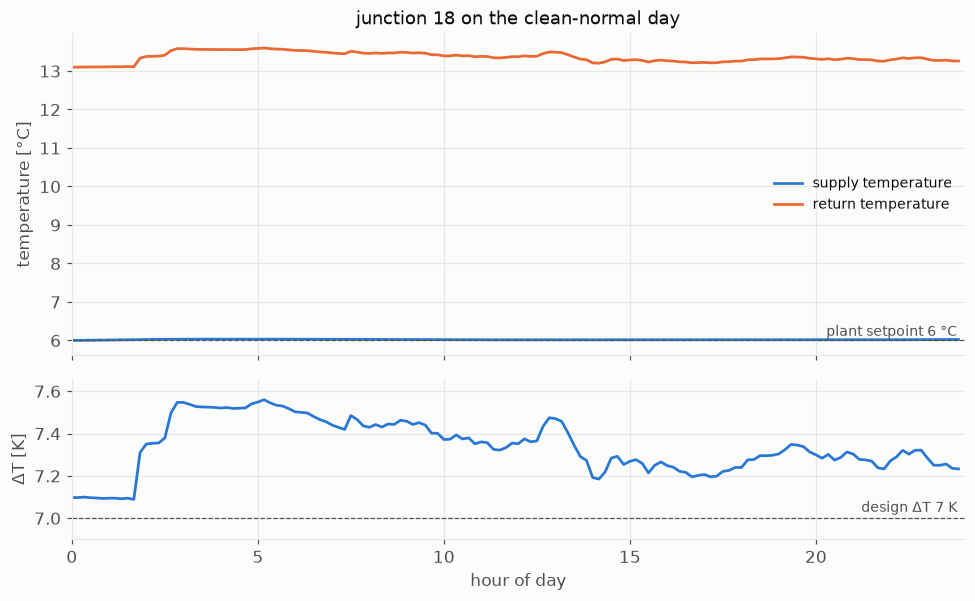

In [6]:
j = fault["location"]  # same junction the leak scenario will strike
sub = nodes_n[nodes_n["junction"] == j].set_index("time_id")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(HOURS, sub["supply_temp"], color=BLUE, lw=1.8, label="supply temperature")
ax1.plot(HOURS, sub["return_temp"], color=ORANGE, lw=1.8, label="return temperature")
ax1.axhline(cfg.thermal.T_supply, color=INK2, lw=0.8, ls="--")
ax1.text(23.8, cfg.thermal.T_supply + 0.12, "plant setpoint 6 °C",
         ha="right", color=INK2, fontsize=9)
ax1.set_ylabel("temperature [°C]")
ax1.set_title(f"junction {j} on the clean-normal day")
ax1.legend(fontsize=9, loc="center right")

ax2.plot(HOURS, sub["dT"], color=BLUE, lw=1.8)
ax2.axhline(cfg.thermal.dT_design, color=INK2, lw=0.8, ls="--")
ax2.set_ylim(6.9, float(sub["dT"].max()) + 0.1)
ax2.text(23.8, cfg.thermal.dT_design + 0.03, "design ΔT 7 K", ha="right", color=INK2, fontsize=9)
ax2.set_ylabel("ΔT [K]")
ax2.set_xlabel("hour of day")
ax2.set_xlim(0, 24)
plt.tight_layout()
plt.show()

## 5 · The leak, seen three ways

At 9.7 h an orifice opens on the **return side of junction 18** (severity: 4.7 % of network design
flow). Three signatures, all in the records:

1. **Make-up flow** — the Plant must replace exactly the water the loop loses. Zero when healthy,
   equal to the realised leak flow while the fault is active. This is on the graph as the plant
   edge's feature, inside a GNN's receptive field.
2. **Local pressure drop** — the extra trunk flow depresses pressure at and around the leak.
3. **Per-timestep labels** — `fault_active`, realised leak-flow series, and the node-granular
   `fault_location_mask`, all aligned with the feature time axis.

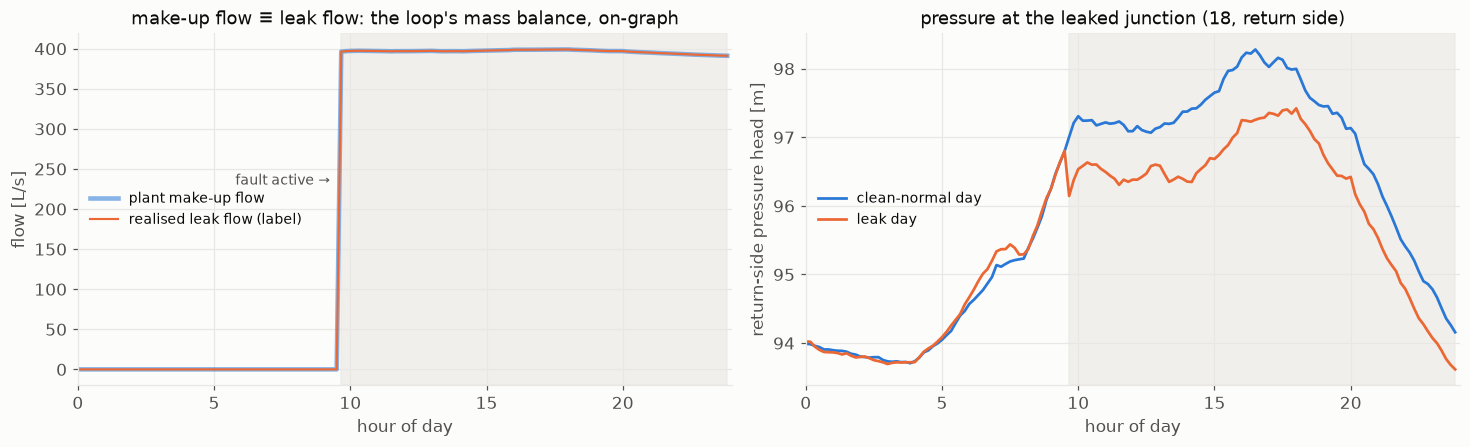

In [7]:
plant_l = table("leak", "plant_dynamics").set_index("time_id")
labels_l = table("leak", "labels").set_index("time_id")
mask = labels_l["fault_active"].to_numpy()
nodes_l = table("leak", "node_dynamics")
p_normal = nodes_n[nodes_n["junction"] == j].set_index("time_id")["pressure_r"]
p_leak = nodes_l[nodes_l["junction"] == j].set_index("time_id")["pressure_r"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax in (ax1, ax2):
    ax.axvspan(HOURS[mask][0], HOURS[mask][-1], color=GRID, alpha=0.6, zorder=0)
    ax.set_xlim(0, 24)
    ax.set_xlabel("hour of day")

ax1.plot(HOURS, plant_l["make_up_flow"] * 1e3, color=BLUE, lw=3, alpha=0.55,
         label="plant make-up flow")
ax1.plot(HOURS, labels_l["realized_leak_flow"] * 1e3, color=ORANGE, lw=1.4,
         label="realised leak flow (label)")
ax1.annotate("fault active →", (HOURS[mask][0] - 0.4, ax1.get_ylim()[1] * 0.55),
             color=INK2, fontsize=9, ha="right")
ax1.set_ylabel("flow [L/s]")
ax1.set_title("make-up flow ≡ leak flow: the loop's mass balance, on-graph")
ax1.legend(fontsize=9, loc="center left")

ax2.plot(HOURS, p_normal, color=BLUE, lw=1.8, label="clean-normal day")
ax2.plot(HOURS, p_leak, color=ORANGE, lw=1.8, label="leak day")
ax2.set_ylabel("return-side pressure head [m]")
ax2.set_title(f"pressure at the leaked junction ({j}, return side)")
ax2.legend(fontsize=9, loc="center left")
plt.tight_layout()
plt.show()

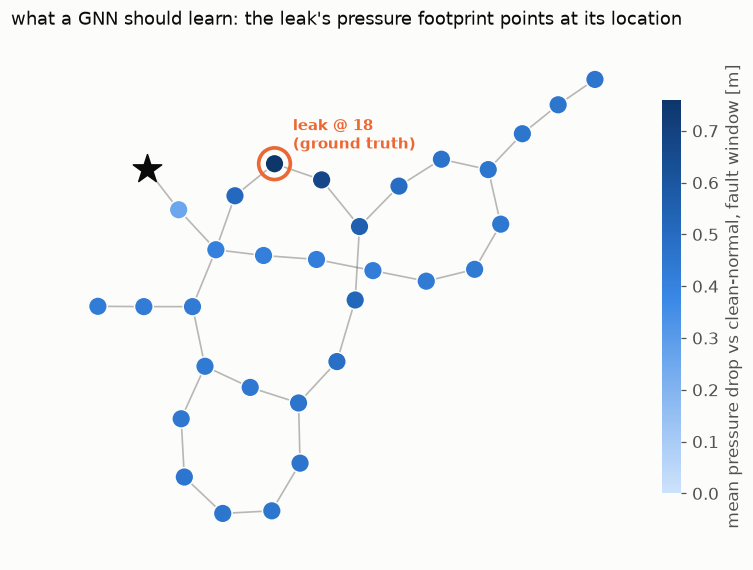

largest mean drop: junction 18 (0.760 m) — ground truth is junction 18


In [8]:
# localisation view: mean return-side pressure drop (normal − leak) over the fault window
drop = {}
for junction in base:
    if junction == site:
        continue
    a = nodes_n[nodes_n["junction"] == junction].set_index("time_id")["pressure_r"].to_numpy()
    b = nodes_l[nodes_l["junction"] == junction].set_index("time_id")["pressure_r"].to_numpy()
    drop[junction] = float((a - b)[mask].mean())

fig, ax = plt.subplots(figsize=(8.5, 6.2))
nx.draw_networkx_edges(base, pos, ax=ax, edge_color=INK2, width=1.1, alpha=0.4)
ordered = [n for n in base if n != site]
values = [drop[n] for n in ordered]
sc = nx.draw_networkx_nodes(base, pos, nodelist=ordered, ax=ax, node_size=150,
                            node_color=values, cmap=SEQ_BLUES, vmin=0,
                            edgecolors=SURFACE, linewidths=1.0)
ax.scatter(*pos[site], marker="*", s=380, color=INK, zorder=5)
ax.scatter(*pos[j], s=430, facecolors="none", edgecolors=ORANGE, linewidths=2.4, zorder=6)
ax.annotate(f"leak @ {j}\n(ground truth)", pos[j], textcoords="offset points",
            xytext=(12, 10), color=ORANGE, fontsize=10, fontweight="bold")
cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("mean pressure drop vs clean-normal, fault window [m]", color=INK2)
cbar.outline.set_visible(False)
ax.set_axis_off()
ax.set_title("what a GNN should learn: the leak's pressure footprint points at its location")
plt.show()
print(f"largest mean drop: junction {max(drop, key=drop.get)} "
      f"({max(drop.values()):.3f} m) — ground truth is junction {j}")

## 6 · The typed heterogeneous graph view (M6a)

The same folders load back as PyTorch-Geometric `HeteroData`: supply/return node types
paired **by index** (ΔT is a positional subtraction), directed pipe edges in mirror orientation,
one ETS crossover edge per consumer, and the plant edge closing the loop. Labels, masks, and the
sensor mask ride along as tensors aligned on the time axis.

In [9]:
from dcngen.records.pyg_dataset import load_scenario

graph = load_scenario(POC / "leak")
print(graph)
print()
supply, ets = graph["supply"], graph["supply", "ets", "return"]
print(f"supply.x            {tuple(supply.x.shape)}   channels: {supply.channels}")
print(f"ets.edge_attr       {tuple(ets.edge_attr.shape)}   channels: {ets.channels}")
plant_edge = graph["return", "plant", "supply"]
print(f"plant.edge_attr     {tuple(plant_edge.edge_attr.shape)}   channels: {plant_edge.channels}")
print()
located = graph["return"].fault_location_mask
print(f"fault_active steps: {int(graph.fault_active.sum())} / {graph.n_steps}")
print(f"fault_location_mask marks: "
      f"{[graph['return'].junction[i] for i in located.nonzero().flatten().tolist()]} "
      f"(ground truth: {fault['location']}, {fault['side']} side)")
print(f"heat-metered consumers: {int(supply.heat_metered.sum())} / {supply.num_nodes} "
      f"(sensor mask, stored beside full ground truth)")

HeteroData(
  network='hanoi_8GB_1Y',
  scenario_id=1,
  seed=7919168045412322066,
  static_draw_id=0,
  dt=600.0,
  n_steps=144,
  time=[144],
  fault={
    element='node',
    kind='leak',
    location='18',
    offset=86400.0,
    onset=34800.0,
    severity=0.0471298108876108,
    side='return',
  },
  fault_active=[144],
  realized_leak_flow=[144],
  converged=[144],
  iterations=[144],
  supply={
    x=[32, 144, 2],
    channels=[2],
    static=[32, 5],
    static_channels=[5],
    junction=[32],
    is_plant=[32],
    is_consumer=[32],
    archetype=[32],
    heat_metered=[32],
    pressure_sensed=[32],
    fault_location_mask=[32],
  },
  return={
    x=[32, 144, 2],
    channels=[2],
    static=[32, 5],
    static_channels=[5],
    junction=[32],
    is_plant=[32],
    is_consumer=[32],
    archetype=[32],
    heat_metered=[32],
    pressure_sensed=[32],
    fault_location_mask=[32],
  },
  (supply, pipe, supply)={
    edge_index=[2, 34],
    edge_attr=[34, 144, 4],
    channe

## What's next

- **Verification harness**: reproduce the small-network scenarios in pandapipes and compare
  temperature/energy fields within configured tolerances (`verify/`).
- **Scale-up**: sampler + parallel driver over all 36 DiTEC topologies, normal + faulty
  splits, DiTEC-style sharding (branch plan: merge `first-working-pipeline` → `main` first).
- **ML phase**: GCN baseline → GAT / physics-informed / spatio-temporal models on detection,
  localisation, and onset tasks.

language). Every figure above reads only `data/poc/` and the DiTEC dump.*